1. Estudio de la estructura del dataset:
- Número de variables y tipo de datos.
- Variable objetivo y naturaleza del problema.

In [ ]:
# Importación de todo lo necesario.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import linear_model


In [ ]:
# Se lee el csv 

df = pd.read_csv("dataset_partida.csv")

In [5]:
df.head()

,x1,x2,resultado
0,-0.125245,0.552601,1
1,0.685084,-0.323315,1
2,0.769488,0.607225,0
3,0.428378,0.157977,1
4,0.075636,0.873185,0


In [ ]:
# Doy valor a X y y con las columnas especificas
X = df.drop(columns=["resultado"])
y = df['resultado']

In [ ]:
# Pinto la distribución de clases

print("Distribución de clases:")
print(y.value_counts())
print("\nPorcentajes:")
print(y.value_counts(normalize=True) * 100)

Distribución de clases:
resultado
0            200
1            200
Name: count, dtype: int64

Porcentajes:
resultado
0            50.0
1            50.0
Name: proportion, dtype: float64


In [ ]:
# Separo X train de X test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((300, 2), (100, 2))

In [ ]:
# Escalo los dato con StandardScaler.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. Justificación del enfoque elegido:
- Argumentación sobre los modelos considerados adecuados.
- Descarte razonado de otros enfoques, si procede.

ENTRENO CON SVM LINEAL

In [ ]:
# Entreno el modelo con SVM Regresión Lineal de primeras

svm_lineal = SVC(kernel="linear", C=1.0, random_state=42)
svm_lineal.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

ENTRENO CON REGRESION LOGISTICA

In [ ]:
# Entreno el modelo con Regresión Logistica

logistica = linear_model.LogisticRegression()
logistica.fit(X_train_scaled, y_train)

LogisticRegression()

ENTRENO CON SVC POLINOMIAL

In [89]:
# Entreno con SVC Polinomial

svm_poly = SVC(kernel="poly", C=0.1, degree=3, coef0=2, random_state=42)
svm_poly.fit(X_train_scaled, y_train)

SVC(C=0.1, coef0=2, kernel='poly', random_state=42)

3. Entrenamiento y evaluación de los modelos seleccionados:
- Uso de métricas adecuadas al problema.
- Comparación razonada de resultados.

MATRIZ DE CONFUSION Y PREDICCIÓN CON REGRESIÓN LINEAL

In [ ]:
# Creamos y pred en base a la precidicción de x test escalado.
y_pred = svm_lineal.predict(X_test_scaled)

In [ ]:
# Calculamos el accuracy del modelo lineal.
pred_lineal = svm_lineal.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred_lineal)*100) 

Accuracy: 92.0


Matriz de confusión:
[[46  4]
 [ 4 46]]


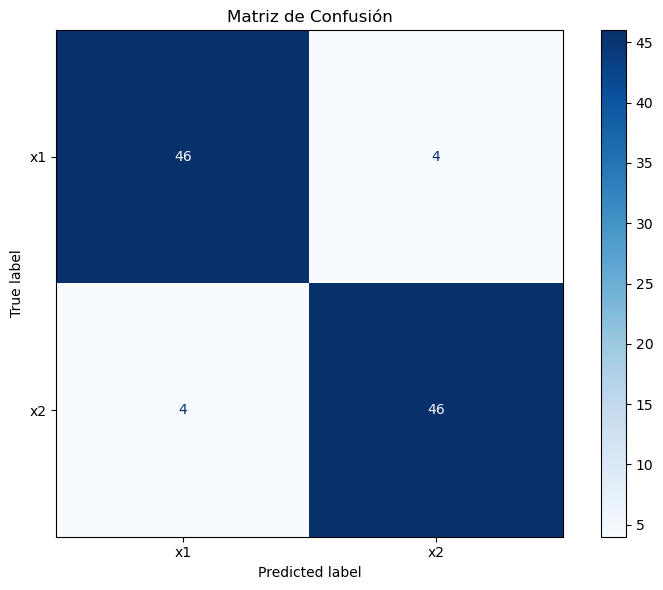

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Recalcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['x1', 'x2'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

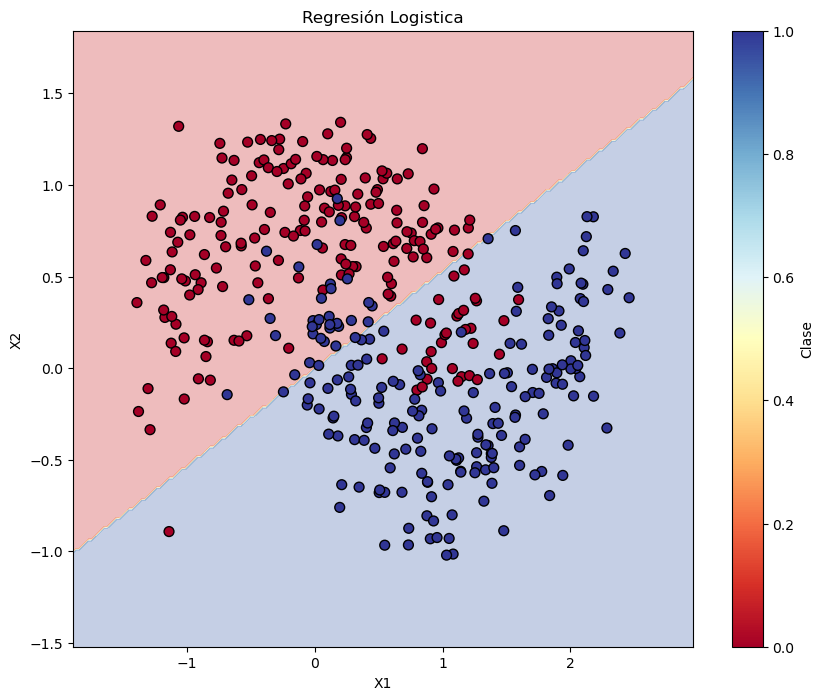

In [80]:
X = df.iloc[:, 0:2].values  
y = df.iloc[:, 2].values

# Crear malla para visualizar la frontera de decisión
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = svm_lineal.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Pintar
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
            edgecolors='black', s=50, linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Regresión Logistica')
plt.colorbar(label='Clase')
plt.show()


MATRIZ DE CONFUSIÓN y PREDICCIÓN CON REGRESIÓN LOGISTICA

In [ ]:
# Creamos y pred en base a la precidicción de x test escalado.
y_pred = logistica.predict(X_test_scaled)

In [ ]:
# Calculamos el accuracy del modelo lineal.
pred_logistica = logistica.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred_logistica)*100) 

Accuracy: 92.0


Matriz de confusión:
[[46  4]
 [ 4 46]]


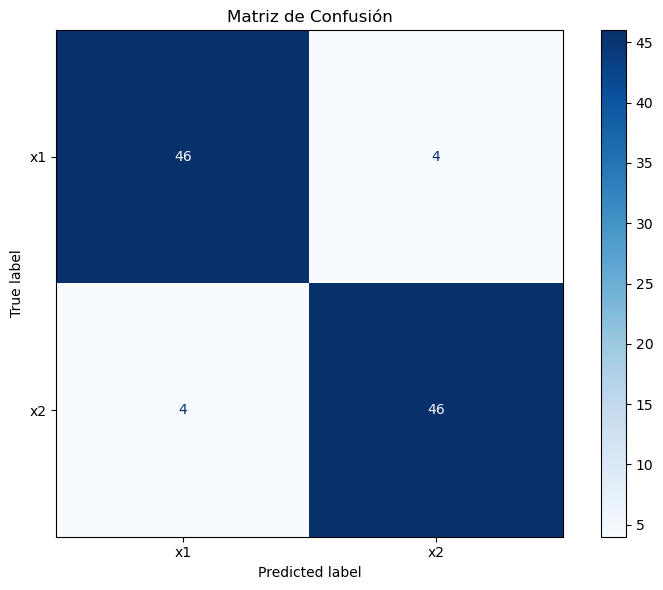

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Recalcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['x1', 'x2'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

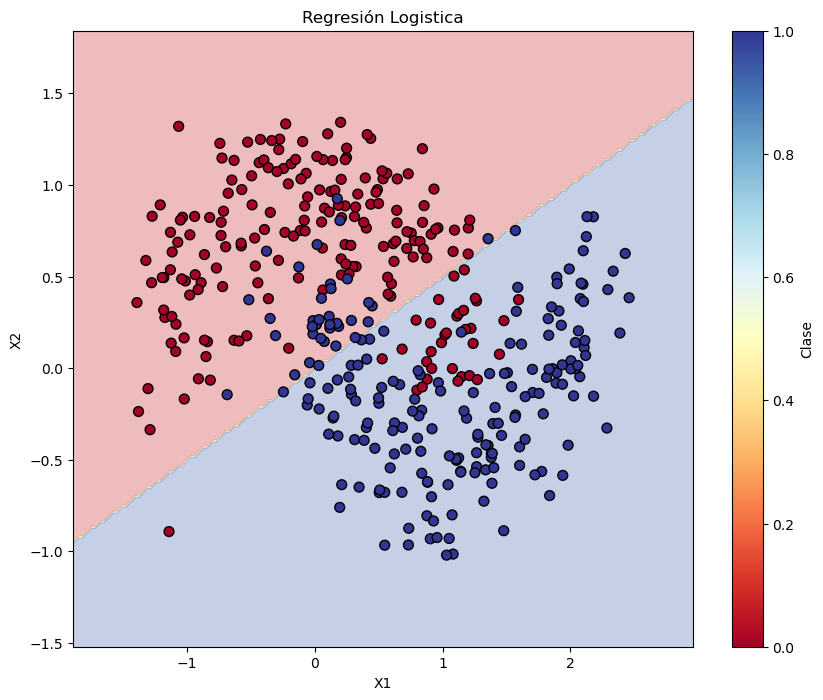

In [59]:
X = df.iloc[:, 0:2].values  
y = df.iloc[:, 2].values

# Crear malla para visualizar la frontera de decisión
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = logistica.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Pintar
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
            edgecolors='black', s=50, linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Regresión Logistica')
plt.colorbar(label='Clase')
plt.show()


MATRIZ DE CONFUSIÓN y PREDICCIÓN CON POLINOMIAL

In [ ]:
# Creamos y pred en base a la precidicción de x test escalado.
y_pred = svm_poly.predict(X_test_scaled)

In [ ]:
# Calculamos el accuracy del modelo lineal.
pred_poly = svm_poly.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred_poly)*100) 

Accuracy: 97.0


Matriz de confusión:
[[41  9]
 [38 12]]


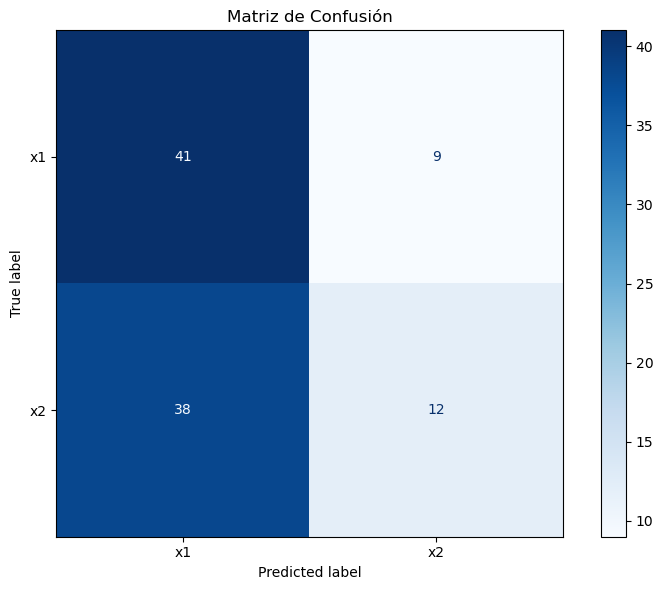

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Recalcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['x1', 'x2'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

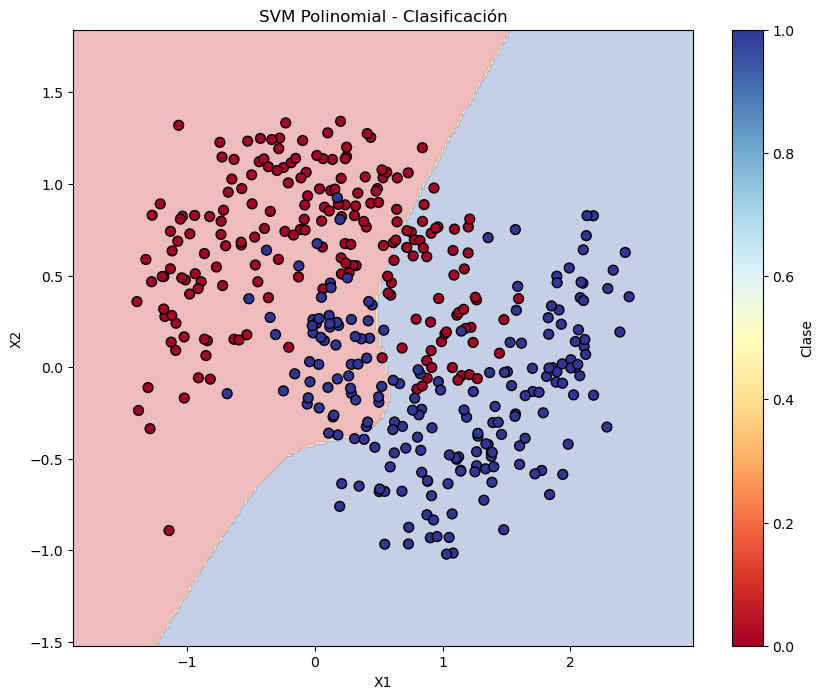

In [64]:
X = df.iloc[:, 0:2].values  
y = df.iloc[:, 2].values

# Crear malla para visualizar la frontera de decisión
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = svm_poly.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Pintar
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', 
            edgecolors='black', s=50, linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('SVM Polinomial - Clasificación')
plt.colorbar(label='Clase')
plt.show()


4. Valoración final:
- Limitaciones del modelo.
- Posibles mejoras o líneas de trabajo futuras.

No podría escogerse un modelo de regresión lineal, porque fijandonos en lo que hemos pintado, debido a que los datos estan bastante mezclados, si se traza una linea a la mitad, al final no dividirias bien los datos.
El modelo que se escogería el polinomial, ya que no se adapta de más a los datos y hace una buena frontera.
Una posible mejora, yo creo que al haber comprobado que con un dataset sencillo, lo que funciona bien es el polinomial, a futuro, de primeras se debería de probar con ese modelo (polinomial).